In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv('Movies_India.csv',encoding='latin-1')
df.head()


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),-2019.0,109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,-2021.0,90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,-2019.0,110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,-2010.0,105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [4]:
df.info

<bound method DataFrame.info of                                      Name    Year Duration            Genre  \
0                                             NaN      NaN            Drama   
1      #Gadhvi (He thought he was Gandhi) -2019.0  109 min            Drama   
2                             #Homecoming -2021.0   90 min   Drama, Musical   
3                                 #Yaaram -2019.0  110 min  Comedy, Romance   
4                       ...And Once Again -2010.0  105 min            Drama   
...                                   ...     ...      ...              ...   
15504                 Zulm Ko Jala Doonga -1988.0      NaN           Action   
15505                               Zulmi -1999.0  129 min    Action, Drama   
15506                           Zulmi Raj -2005.0      NaN           Action   
15507                       Zulmi Shikari -1988.0      NaN           Action   
15508                        Zulm-O-Sitam -1998.0  130 min    Action, Drama   

       Rating Votes

In [5]:
df.shape # (number of rows, number of columns)  

(15509, 10)

In [6]:
df.info() # Display information about the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  float64
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(2), object(8)
memory usage: 1.2+ MB


In [7]:
df.dtypes

Name         object
Year        float64
Duration     object
Genre        object
Rating      float64
Votes        object
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object

In [8]:
df.describe()

,Year,Rating
count,14981.000000,7919.000000
mean,-1987.012215,5.841621
std,25.416689,1.381777
min,-2022.000000,1.100000
25%,-2009.000000,4.900000
50%,-1991.000000,6.000000
75%,-1968.000000,6.800000
max,-1913.000000,10.000000


In [9]:
df.isnull()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,False,True,True,False,True,True,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,True,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
15504,False,False,True,False,False,False,False,False,False,False
15505,False,False,False,False,False,False,False,False,False,False
15506,False,False,True,False,True,True,False,False,True,True
15507,False,False,True,False,True,True,True,True,True,True


In [10]:
df.isnull().sum() # Check for missing values in each column

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [11]:
df.duplicated().sum() # Check for duplicate rows in the DataFrame

np.int64(6)

In [12]:
df = df.drop_duplicates() # Remove duplicate rows from the DataFrame

In [13]:
df.duplicated().sum() # Check for duplicate rows again after dropping duplicates

np.int64(0)

In [14]:
df = df.dropna(subset=['Rating']) # Drop rows with missing values in the 'Rating' column    


In [15]:
df["Year"] = df["Year"].fillna(df["Year"].median()) # Convert the 'Year' column to integer type
df["Duration"] = df["Duration"].str.replace(' min', '', regex=False) # Convert the 'Duration' column to integer type
df["Duration"] = pd.to_numeric(df["Duration"],errors = "coerce") # Convert the 'Duration' column to integer type
df["Votes"] = pd.to_numeric(df["Votes"],errors = "coerce") # Convert the 'Votes' column to integer type


In [16]:
df["Duration"]=df["Duration"].fillna(df["Duration"].median()) # Fill missing values in the 'Duration' column with the median value  
df["Votes"]=df["Votes"].fillna(df["Votes"].median()) # Fill missing values in the 'Votes' column with the median value  

df["Year"] = df["Year"].fillna(df["Year"].median()) # Fill missing values in the 'Year' column with the median value

df["Genre"] = df["Genre"].fillna(df["Genre"].mode()[0]) # Fill missing values in the 'Genre' column with "Unknown"

df['Director'] = df['Director'].fillna('Unknown') # Fill missing values in the 'Director' column with "Unknown"
df['Actor 1'] = df['Actor 1'].fillna('Unknown') # Fill missing values in the 'Actor 1' column with "Unknown"
df['Actor 2'] = df['Actor 2'].fillna('Unknown') # Fill missing values in the 'Actor 2' column with "Unknown"    
df['Actor 3'] = df['Actor 3'].fillna('Unknown') # Fill missing values in the 'Actor 3' column with "Unknown"        

df=df.dropna(subset=['Rating']) # Drop rows with missing values in the 'Rating' column

In [17]:
df.isnull().sum() # Check for missing values in each column

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

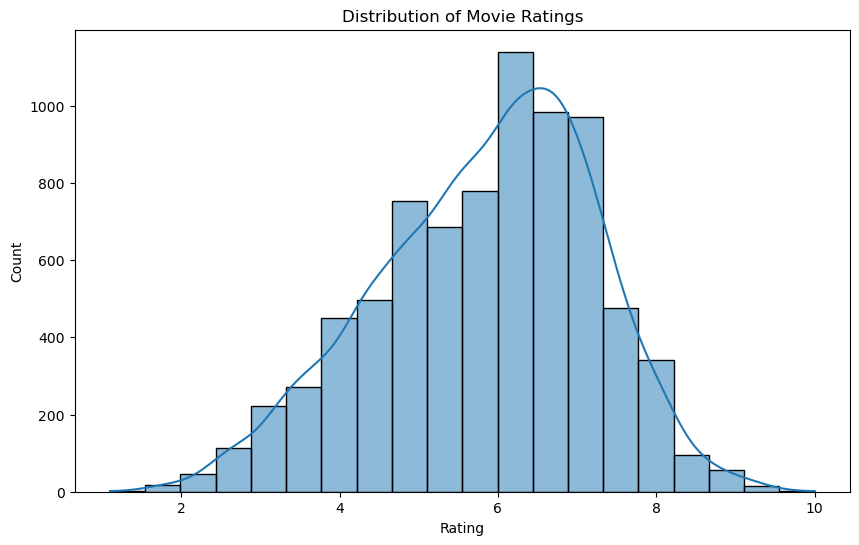

In [18]:
# Rating distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title('Distribution of Movie Ratings')  
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

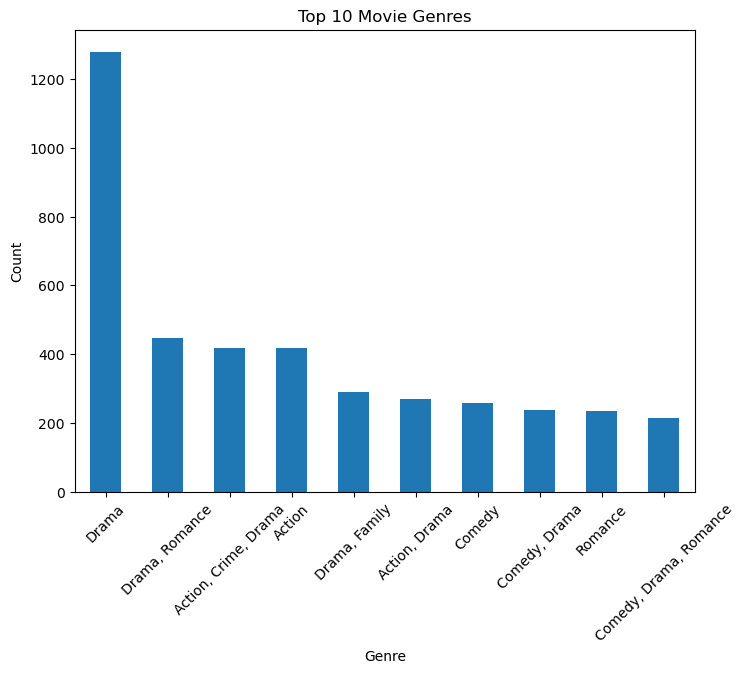

In [19]:
#Top 10 Genres
plt.figure(figsize=(8, 6))
df['Genre'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()  

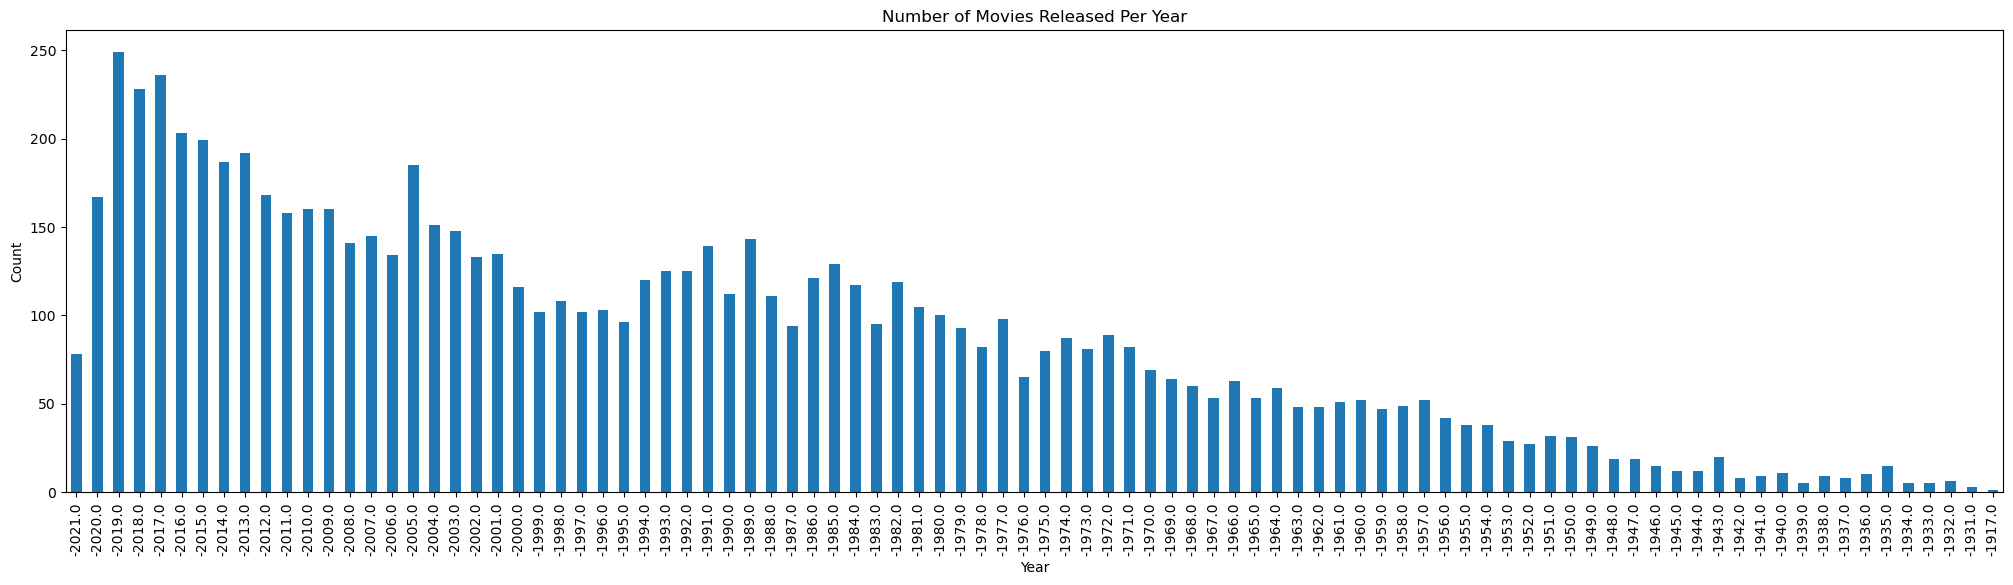

In [20]:
# Movie Released Per Year
plt.figure(figsize=(25, 6))
df['Year'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

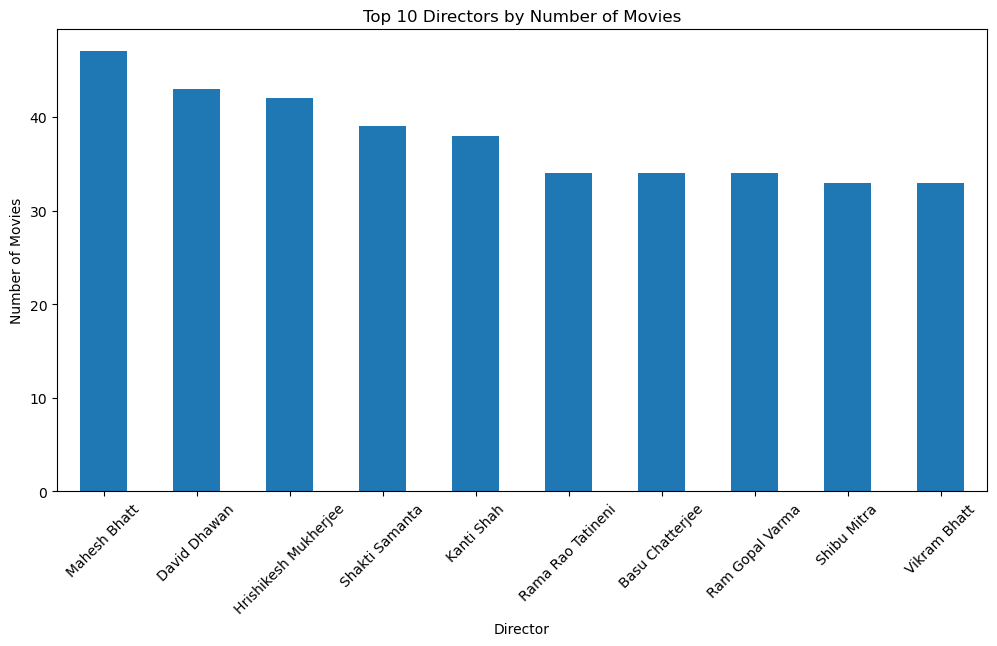

In [21]:
# Top 10 Directors
df['Director'].value_counts().head(10).plot(kind='bar', figsize=(12, 6))
plt.title('Top 10 Directors by Number of Movies')
plt.xlabel('Director')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

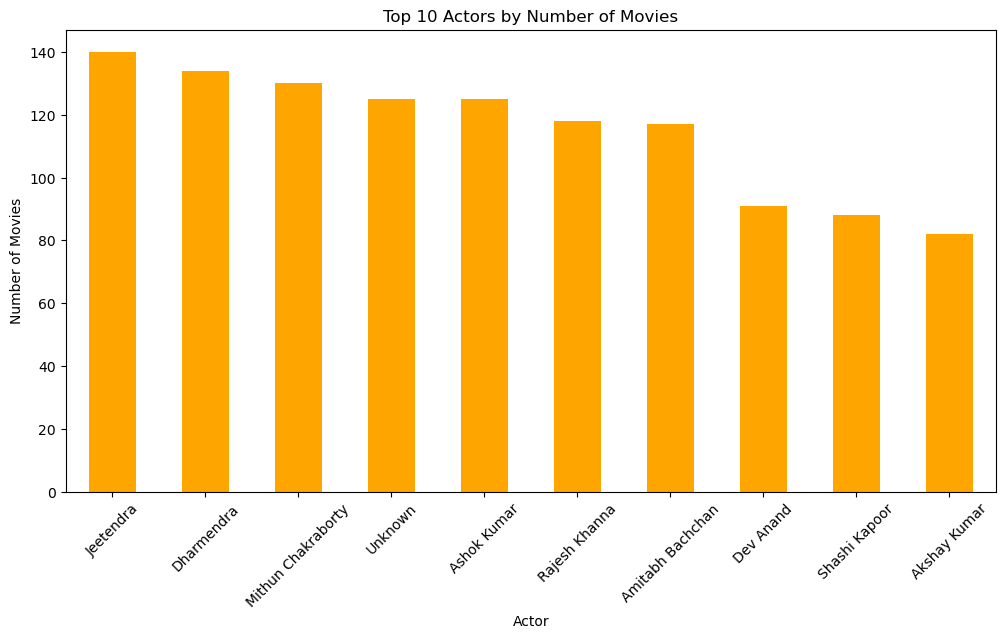

In [22]:
# Top 10 Actors 
df['Actor 1'].value_counts().head(10).plot(kind='bar', figsize=(12, 6), color='orange')
plt.title('Top 10 Actors by Number of Movies')
plt.xlabel('Actor')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

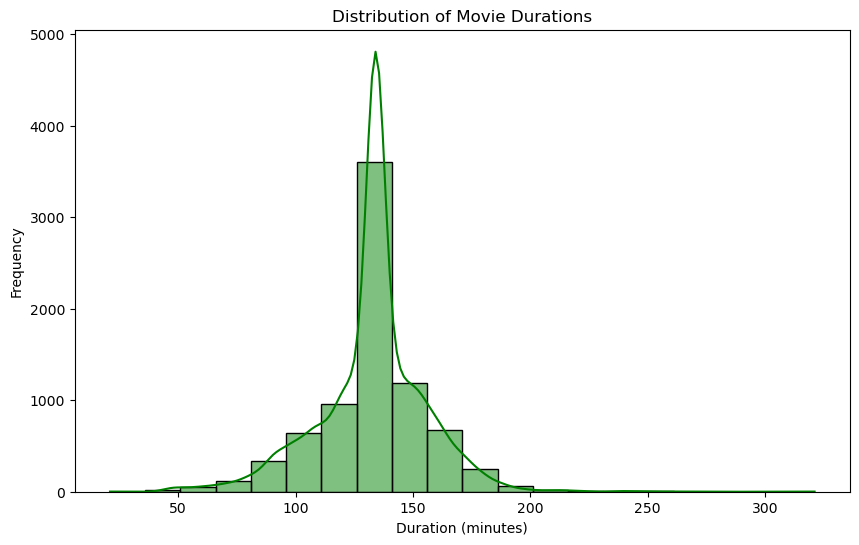

In [23]:
# Duration distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Duration'], bins=20, kde=True, color='green')
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

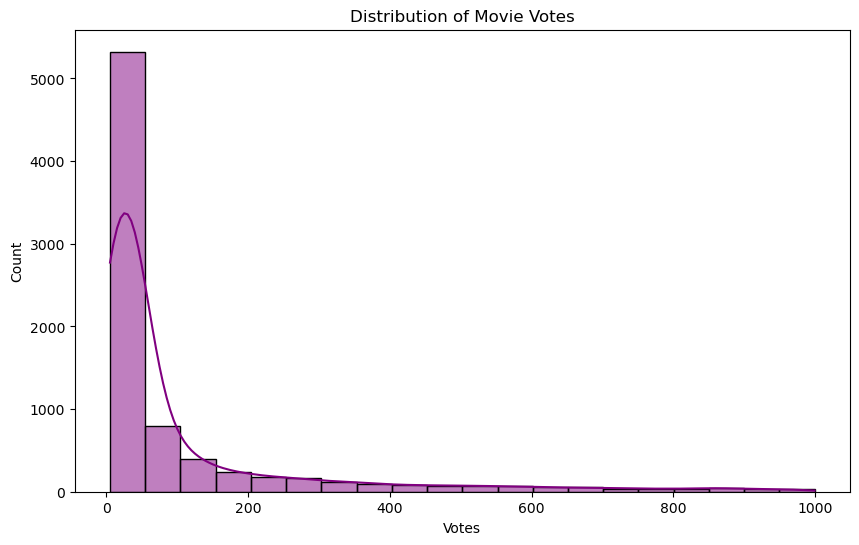

In [24]:
# votes distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Votes'], bins=20, kde=True, color='purple')
plt.title('Distribution of Movie Votes')
plt.xlabel('Votes')
plt.ylabel('Count')
plt.show()

In [25]:
df.dtypes


Name         object
Year        float64
Duration    float64
Genre        object
Rating      float64
Votes       float64
Director     object
Actor 1      object
Actor 2      object
Actor 3      object
dtype: object

In [26]:
df['Votes'].sample(20)

3448     191.0
8974      35.0
852       11.0
9257      30.0
11212     30.0
886       23.0
11165     35.0
11309     54.0
466       35.0
5978      12.0
8571     112.0
801       35.0
6524      43.0
12495     33.0
2702       5.0
12192     23.0
3612      50.0
9097      22.0
11637    475.0
10976      7.0
Name: Votes, dtype: float64

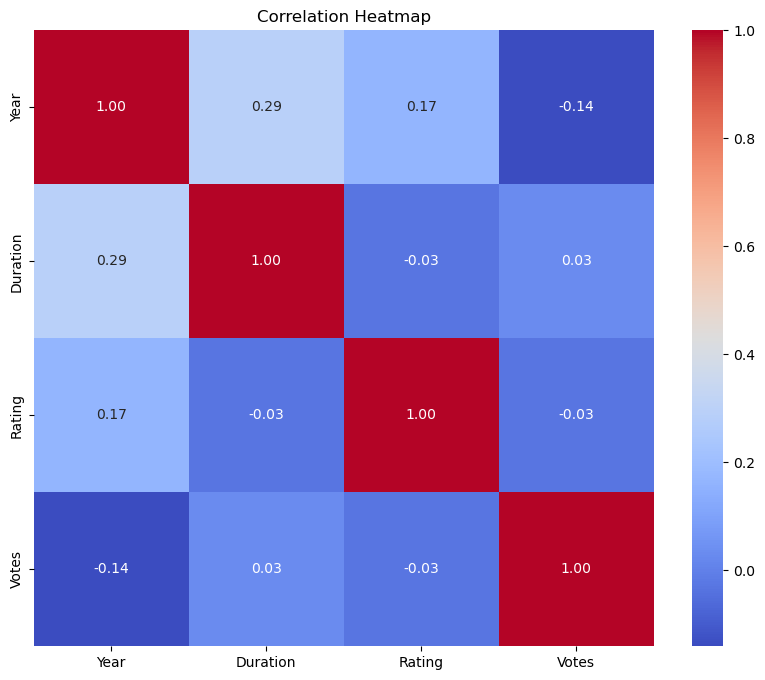

In [27]:
num_df = df.select_dtypes(include=[np.number])  # Select only numeric columns for correlation analysis
plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

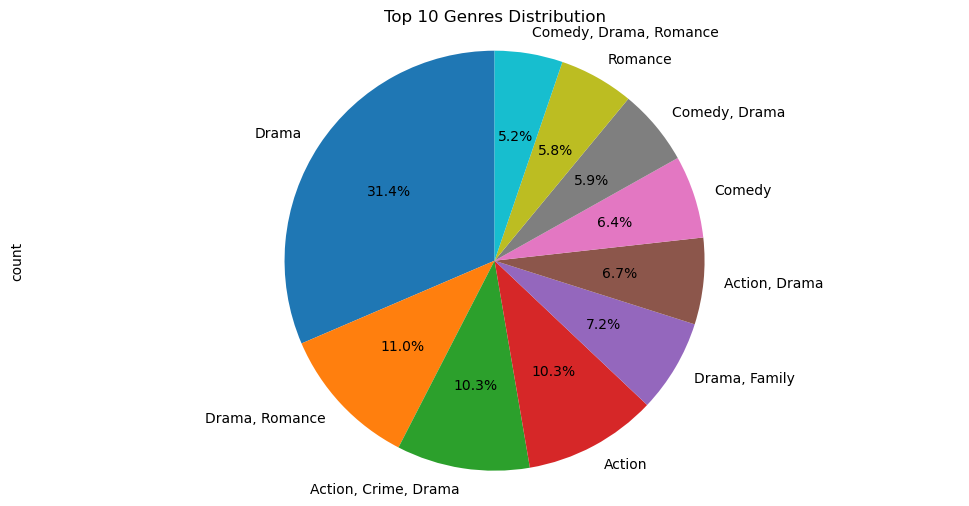

In [28]:
# Genre Distribution
plt.figure(figsize=(12, 6))


df['Genre'].value_counts().head(10).plot(kind='pie', color='teal',autopct='%1.1f%%', startangle=90)
plt.title('Top 10 Genres Distribution')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


C:\Users\Rohit Singh\AppData\Local\Temp\ipykernel_7324\1514391079.py:115: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels() , color = 'white' , fontsize = 15)
C:\Users\Rohit Singh\AppData\Local\Temp\ipykernel_7324\1514391079.py:116: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels() , color = 'white' , fontsize = 15)
C:\Users\Rohit Singh\AppData\Local\Temp\ipykernel_7324\1514391079.py:125: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels() , color = 'white' , fontsize = 15)
C:\Users\Rohit Singh\AppData\Local\Temp\ipykernel_7324\1514391079.py:126: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. afte

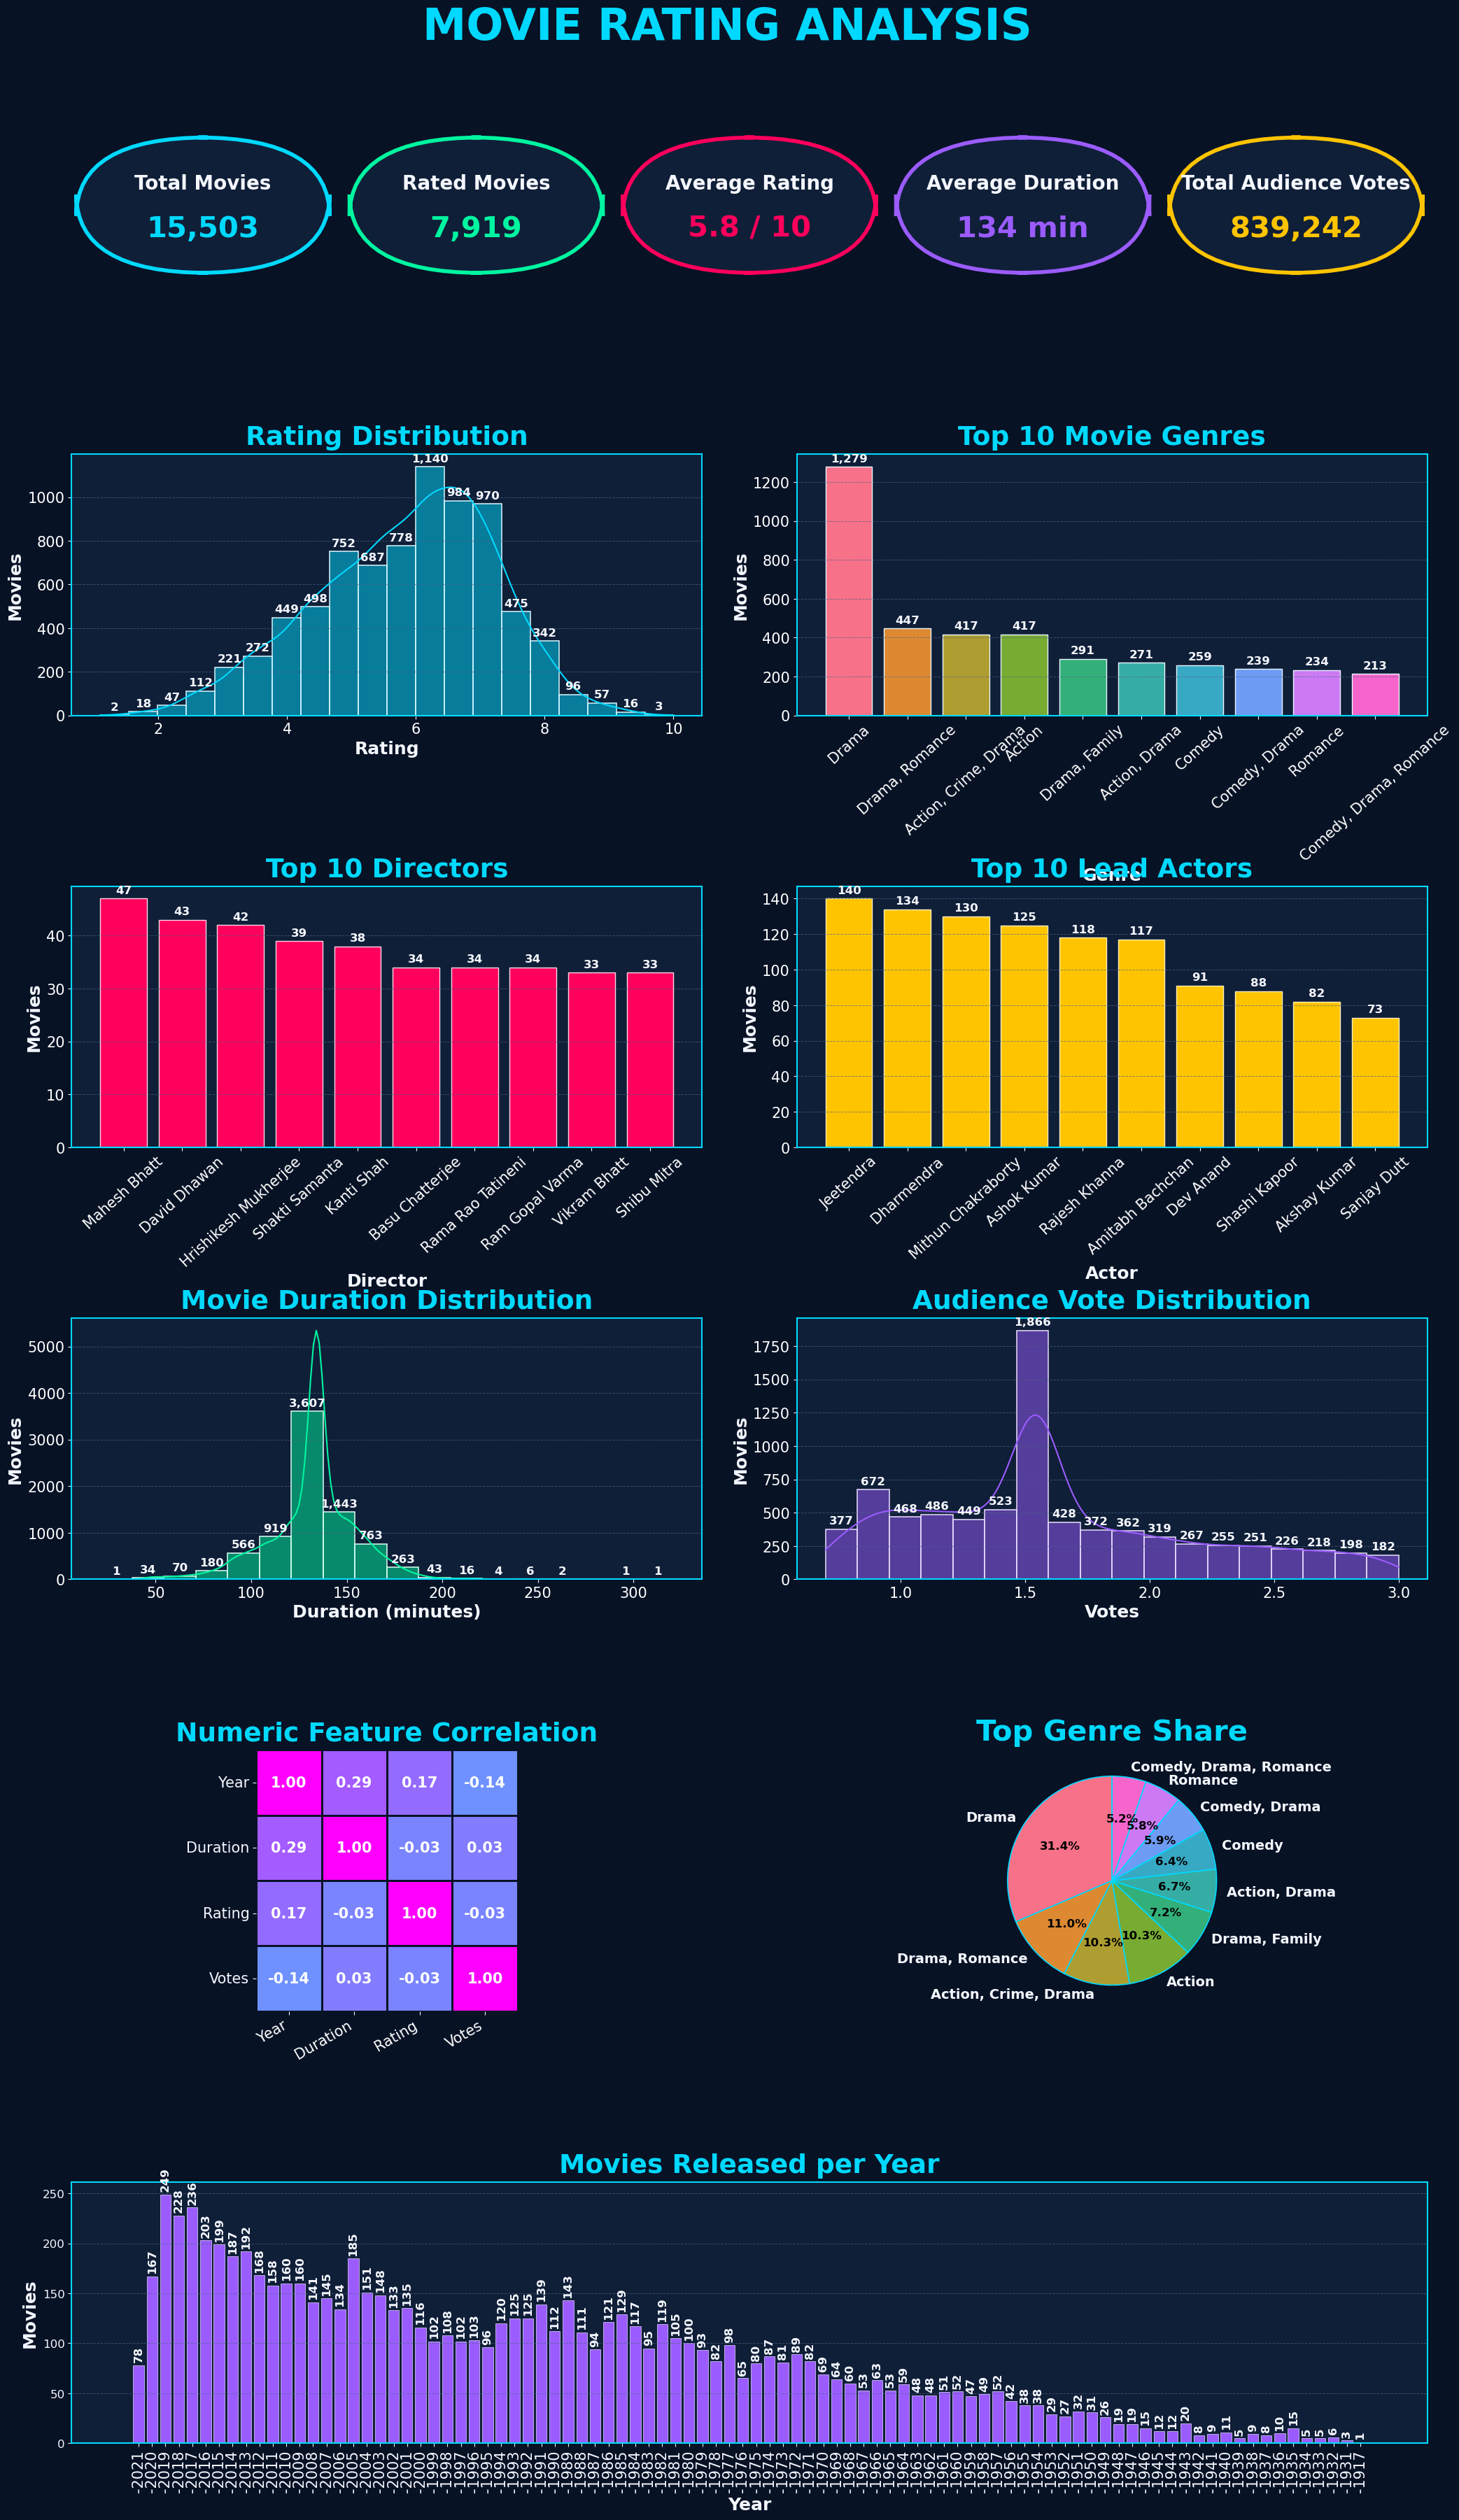

In [29]:
from matplotlib.patches import FancyBboxPatch
from pathlib import Path

# Create the cleaned dashboard DataFrame before it is used in the KPI cards.
# if 'df' not in globals():
#     df = pd.read_csv('Movies_India.csv', encoding='latin-1').drop_duplicates()
#     df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
#     df = df.dropna(subset=['Rating'])
#     df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
#     df['Duration'] = pd.to_numeric(df['Duration'].astype(str).str.replace(' min', '', regex=False), errors='coerce')
#     df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
#     df['Duration'] = df['Duration'].fillna(df['Duration'].median())
#     df['Votes'] = df['Votes'].fillna(df['Votes'].median())
#     df['Genre'] = df['Genre'].fillna(df['Genre'].mode()[0])
#     df['Director'] = df['Director'].fillna('Unknown')
#     df['Actor 1'] = df['Actor 1'].fillna('Unknown')

dashboard_df = df.copy()
# Total movies counts every unique record, including movies with no rating.
total_movies = len(pd.read_csv('Movies_India.csv', encoding='latin-1').drop_duplicates())
# for column in ['Rating', 'Year', 'Duration', 'Votes']:
#     dashboard_df[column] = pd.to_numeric(dashboard_df[column], errors='coerce')


# Dashboard palette
BG = "#081225"
PANEL = "#101f38"
GRID = "#4b6385"
TEXT = "#f4f7ff"
MUTED = "#aebed5"
CYAN = "#00d9ff"
MINT = "#00f5a0"
PINK = "#ff005c"
GOLD = "#ffc400"
PURPLE = "#9b5cff"


def style_panel(ax, title, xlabel="", ylabel=""):
    ax.set_facecolor(PANEL)
    for spine in ax.spines.values():
        spine.set_color(CYAN)
        spine.set_linewidth(1.5)
    ax.tick_params(colors=TEXT, labelsize=12)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.set_xlabel(xlabel, color=TEXT, fontweight="bold" , fontsize="18")
    ax.set_ylabel(ylabel, color=TEXT, fontweight="bold",fontsize="18")
    ax.set_title(title, color=CYAN, fontsize=27, fontweight="bold", pad=10)
    ax.grid(axis="y", color=GRID, linestyle="--", linewidth=0.7, alpha=0.65)


def label_bars(ax, fontsize=15, rotation=0):
                                               #Show a value above every bar in a bar/histogram chart.
    for bar in ax.patches:
        height = bar.get_height()
        if np.isfinite(height) and height > 0:
            ax.annotate(
                f"{height:,.0f}",
                (bar.get_x() + bar.get_width() / 2, height),
                ha="center",
                va="bottom",
                xytext=(0, 3),
                textcoords="offset points",
                color=TEXT,
                fontsize=fontsize,
                fontweight="bold",
                rotation=rotation,
            )


def add_kpi_card(ax, label, value, color):
    ax.set_axis_off()
    card = FancyBboxPatch(
        (0.03, 0.08), 0.94, 0.84,
        boxstyle="round,pad=0.012,rounding_size=0.50",
        linewidth=4,
        edgecolor=color,
        facecolor=PANEL,
        transform=ax.transAxes,
    )
    ax.add_patch(card)
    ax.text(0.5, 0.64, label, ha="center", va="center", color=TEXT,
            fontsize=20, fontweight="bold", transform=ax.transAxes)
    ax.text(0.5, 0.35, value, ha="center", va="center", color=color,
            fontsize=30, fontweight="bold", transform=ax.transAxes)


fig = plt.figure(figsize=(25, 43), facecolor=BG)
outer = fig.add_gridspec(6, 2, height_ratios=[1.5, 2.5,2.5,2.5,2.5,2.5], hspace=0.7, wspace=0.15)
fig.suptitle("MOVIE RATING ANALYSIS", color=CYAN, fontsize=45,
             fontweight="bold", y=0.92)


# KPI cards
kpi_grid = outer[0, :].subgridspec(1, 5, wspace=0.04)
add_kpi_card(fig.add_subplot(kpi_grid[0]), "Total Movies", f"{total_movies:,}", CYAN)
add_kpi_card(fig.add_subplot(kpi_grid[1]), "Rated Movies", f"{dashboard_df['Rating'].notna().sum():,}", MINT)
add_kpi_card(fig.add_subplot(kpi_grid[2]), "Average Rating", f"{dashboard_df['Rating'].mean():.1f} / 10", PINK)
add_kpi_card(fig.add_subplot(kpi_grid[3]), "Average Duration", f"{dashboard_df['Duration'].median():.0f} min", PURPLE)
add_kpi_card(fig.add_subplot(kpi_grid[4]), "Total Audience Votes", f"{dashboard_df['Votes'].sum():,.0f}", GOLD)
axes = []
for row in range(1, 5):
    for col in range(2):
        axes.append(fig.add_subplot(outer[row, col]))

# Last row -> full width
axes.append(fig.add_subplot(outer[5, :]))

# 1. Rating distribution
ax = axes[0]
sns.histplot(dashboard_df["Rating"].dropna(), bins=20, kde=True, color=CYAN,
             edgecolor="#d8f7ff", linewidth=1.1, ax=ax)
style_panel(ax, "Rating Distribution", "Rating", "Movies")
label_bars(ax, fontsize=12)
ax.set_xticklabels(ax.get_xticklabels() , color = 'white' , fontsize = 15)
ax.set_yticklabels(ax.get_yticklabels() , color = 'white' , fontsize = 15)

# 2. Top genres
ax = axes[1]
genres = dashboard_df["Genre"].value_counts().head(10)
bars = ax.bar(genres.index, genres.values, color=sns.color_palette("husl", len(genres)), edgecolor="#eaf6ff")
style_panel(ax, "Top 10 Movie Genres", "Genre", "Movies")
ax.tick_params(axis="x", rotation=42)
label_bars(ax, fontsize=12)
ax.set_xticklabels(ax.get_xticklabels() , color = 'white' , fontsize = 15)
ax.set_yticklabels(ax.get_yticklabels() , color = 'white' , fontsize = 15)



# 4. Top directors
ax = axes[2]
directors = dashboard_df["Director"].replace("Unknown", np.nan).dropna().value_counts().head(10)
ax.bar(directors.index, directors.values, color=PINK, edgecolor="#ffd7e7")
style_panel(ax, "Top 10 Directors", "Director", "Movies")
ax.tick_params(axis="x", rotation=42)
label_bars(ax, fontsize=12)
ax.set_xticklabels(ax.get_xticklabels() , color = 'white' , fontsize = 15)
ax.set_yticklabels(ax.get_yticklabels() , color = 'white' , fontsize = 15)

# 5. Top actors
ax = axes[3]
actors = dashboard_df["Actor 1"].replace("Unknown", np.nan).dropna().value_counts().head(10)
ax.bar(actors.index, actors.values, color=GOLD, edgecolor="#fff1bd")
style_panel(ax, "Top 10 Lead Actors", "Actor", "Movies")
ax.tick_params(axis="x", rotation=42)
label_bars(ax, fontsize=12)
ax.set_xticklabels(ax.get_xticklabels() , color = 'white' , fontsize = 15)
ax.set_yticklabels(ax.get_yticklabels() , color = 'white' , fontsize = 15)

# 6. Duration distribution
ax = axes[4]
sns.histplot(dashboard_df["Duration"].dropna(), bins=18, kde=True, color=MINT,
             edgecolor="#dcfff3", linewidth=1.1, ax=ax)
style_panel(ax, "Movie Duration Distribution", "Duration (minutes)", "Movies")
label_bars(ax, fontsize=12)
ax.set_xticklabels(ax.get_xticklabels() , color = 'white' , fontsize = 15)
ax.set_yticklabels(ax.get_yticklabels() , color = 'white' , fontsize = 15)

# 7. Votes distribution
ax = axes[5]
vote_values = np.log10(dashboard_df.loc[dashboard_df["Votes"] > 0, "Votes"])
sns.histplot(vote_values, bins=18, kde=True, color=PURPLE, edgecolor="#eadfff", linewidth=1.1, ax=ax)
style_panel(ax, "Audience Vote Distribution", "Votes", "Movies")
label_bars(ax, fontsize=12)
ax.set_xticklabels(ax.get_xticklabels() , color = 'white' , fontsize = 15)
ax.set_yticklabels(ax.get_yticklabels() , color = 'white' , fontsize = 15)

# 8. Correlation heatmap
ax = axes[6]
numeric = dashboard_df[["Year", "Duration", "Rating", "Votes"]].corr()
sns.heatmap(numeric, annot=True, fmt=".2f", cmap="cool", center=0, linewidths=1,
            linecolor=BG, cbar=False, square=True, annot_kws={"size": 15, "weight": "bold"}, ax=ax)
style_panel(ax, "Numeric Feature Correlation" ,)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", color='white' , fontsize = 15)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color=TEXT , fontsize = 15)
ax.grid(False)

# 9. Genre share
ax = axes[7]
pie_colors = sns.color_palette("husl", len(genres))
wedges, _, autotexts = ax.pie(genres.values, labels=genres.index, autopct="%1.1f%%",
                               startangle=90, colors=pie_colors,
                               wedgeprops={"edgecolor": CYAN, "linewidth": 1.2},
                               textprops={"color": TEXT, "fontsize": 14 , "fontweight":'bold'})
for text in autotexts:
    text.set_fontweight("bold")
    text.set_fontsize('12')
    text.set_color('black')
ax.set_facecolor(PANEL)
ax.set_title("Top Genre Share", color=CYAN, fontsize=30, fontweight="bold", pad=10)

 #3. Releases per year
ax = axes[8]
yearly = dashboard_df["Year"].dropna().round().astype(int).value_counts().sort_index()
ax.bar(yearly.index.astype(str), yearly.values, color=PURPLE, edgecolor="#e3d7ff", linewidth=0.5)
style_panel(ax, "Movies Released per Year", "Year", "Movies")
ax.tick_params(axis="x", rotation=90, labelsize=15)
label_bars(ax, fontsize=12, rotation=90)

plt.show()



